In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'png'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvZml0c2wvZGV2L3NpbXBsZXItbGV0dGVyYm94ZC9RdWFydG8='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/importlib/_bootstrap.py": 1771974507.315756, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/importlib/_bootstrap_external.py": 1771974507.3187559, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/zipimport.py": 1771974506.3617537, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/codecs.py": 1771974506.059753, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/encodings/aliases.py": 1771974506.7167544, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/encodings/__init__.py": 1771974506.7117546, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/encodings/utf_8.py": 1771974507.0237553, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/abc.py": 1771974506.0257528, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/stat.py": 1771974506.2887535, "/home/fitsl/miniconda3/envs/simple-tropeogram/lib/python3.14/_collections_abc.py": 1771

In [2]:
import sys, os
from pathlib import Path

_project_root = Path.cwd().parent
os.chdir(_project_root)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

print("Parent Included")

Parent Included


In [3]:
from pathlib import Path
import random

import srt
import pandas as pd
import chardet
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  

from src.hedonometer import parse_text, import_hedonometer_as_dict

In [4]:
# constants 
plt.style.use(["ggplot"])
IMG_WIDTH = 12
sns.color_palette("muted")

[(0.2823529411764706, 0.47058823529411764, 0.8156862745098039),
 (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),
 (0.41568627450980394, 0.8, 0.39215686274509803),
 (0.8392156862745098, 0.37254901960784315, 0.37254901960784315),
 (0.5843137254901961, 0.4235294117647059, 0.7058823529411765),
 (0.5490196078431373, 0.3803921568627451, 0.23529411764705882),
 (0.8627450980392157, 0.49411764705882355, 0.7529411764705882),
 (0.4745098039215686, 0.4745098039215686, 0.4745098039215686),
 (0.8352941176470589, 0.7333333333333333, 0.403921568627451),
 (0.5098039215686274, 0.7764705882352941, 0.8862745098039215)]

In [5]:
srt_file = Path(
    "Data/subtitles/Fellowship Of The Ring 2001 [Extended Edition] SDH-en.srt"
)
with open(srt_file, "r") as f:
    subtitle_generator = srt.parse(f.read())
subtitles = list(subtitle_generator)
subtitle_df = pd.DataFrame(
    [{"start": s.start, "end": s.end, "content": s.content} for s in subtitles]
)
subtitle_df["start"] = subtitle_df["start"].dt.total_seconds()
subtitle_df["end"] = subtitle_df["end"].dt.total_seconds()
subtitle_df = subtitle_df.sort_values(by="start", ascending=True)
subtitle_df.head()

,start,end,content
0,31.571,34.490,[FEMALE WHISPERS IN ELVISH]
1,34.491,37.743,FEMALE VOICE:\nThe world <i>is</i> changed.
2,37.744,41.497,<i>I feel it in the water.</i>
3,41.498,46.001,<i>I feel it in the earth.</i>
4,46.002,49.421,<i>I smell it in the air.</i>


In [6]:
subtitle_df["content"] = subtitle_df["content"].str.replace("\n", " ")
subtitle_df["content"] = subtitle_df["content"].str.replace("<i>", " ")
subtitle_df["content"] = subtitle_df["content"].str.replace("</i>", " ")
subtitle_df["content"] = subtitle_df["content"].apply(parse_text)

In [7]:
subtitle_df['wordcount']  = subtitle_df['content'].str.len()
print(subtitle_df['wordcount'].sum())
subtitle_df.to_csv("Data/subtitle-dataframes/fellowship-of-the-ring.csv")

15050


In [8]:
trope_file = Path("Data/trope_time_series/Fellowship_of_the_Ring_filled_copy.csv")
with open(trope_file, "rb") as f:
    encoding = chardet.detect(f.read())["encoding"]
trope_df = pd.read_csv(
    "Data/trope_time_series/Fellowship_of_the_Ring_filled_copy.csv", encoding=encoding
)
trope_df["start"] = pd.to_timedelta(
    trope_df["Start Time"], errors="coerce"
).dt.total_seconds()
trope_df["end"] = pd.to_timedelta(
    trope_df["End Time"], errors="coerce"
).dt.total_seconds()
trope_df.head()

,Trope,Description,Inverted?/Defied?,Averted/Subverted?,Rough Occurence in movie,book_movie_weirdness,Background?,sig_scene,Setups?,Start Time,End Time,Total Time,start,end
0,Rule of Symbolism,Jackson bows to Tolkien with subtle grace: the...,NaN,NaN,NaN,NaN,Timing captures the movie in total darkness,MYTH NARRATION,NaN,00:00:28,00:01:03,NaN,28.0,63.0
1,Adaptational Context Change,Galadriel's iconic introductory voice-over wa...,NaN,NaN,NaN,x,NaN,MYTH NARRATION,NaN,00:00:28,00:07:32,NaN,28.0,452.0
2,Opening Monologue,Galadriel's now iconic opening monologue of t...,NaN,NaN,NaN,NaN,NaN,MYTH NARRATION,NaN,00:01:07,00:07:32,NaN,67.0,452.0
3,Distant Prologue,The movie starts with Galadriel narrating sev...,NaN,NaN,NaN,NaN,NaN,MYTH NARRATION,NaN,00:01:07,00:07:32,NaN,67.0,452.0
4,War Was Beginning,The movie starts with Galadriel narrating a h...,NaN,NaN,NaN,NaN,"End when Sauron ""died""",MYTH NARRATION,NaN,00:01:07,00:04:18,NaN,67.0,258.0


In [9]:
trope_df['Description'] = trope_df['Description'].apply(parse_text) 
trope_df["wordcount"] = trope_df["Description"].str.len()
trope_df["wordcount"].sum()

np.float64(17664.0)

In [10]:
def assign_happiness(data, lens_size, labmt: dict )-> np.ndarray:
    happiness_scores = np.array([labmt.get(word, np.nan) for word in data])
    happiness_scores = np.where(
        (happiness_scores < 5 - lens_size) | (happiness_scores > 5 + lens_size),
        happiness_scores,
        np.nan,
    )
    return happiness_scores

In [11]:
def sliding_window_scores(
    window_start,
    window_end,
    lens_size,
    labmt,
    subs: pd.DataFrame,
    tropes: pd.DataFrame,
):
    sub_tokens = []
    for _, row in subs.iterrows():
        if window_start <= row["start"] < window_end and isinstance(
            row["content"], list
        ):
            sub_tokens += row["content"]

    seen_tropes = set()
    trope_tokens = []
    for _, row in tropes.iterrows():
        key = (row["start"], row["end"])
        if (
            key not in seen_tropes
            and row["start"] < window_end
            and row["end"] > window_start
        ):
            trope_tokens += row["Description"]
            seen_tropes.add(key)

    sub_hs = assign_happiness(sub_tokens, lens_size, labmt)
    trope_hs = assign_happiness(trope_tokens, lens_size, labmt)
    return sub_hs, trope_hs

In [12]:
def aggregate_scores(sub_hs, trope_hs, alpha):
    sub_score = np.nan if np.all(np.isnan(sub_hs)) else np.nanmean(sub_hs)
    trope_score = np.nan if np.all(np.isnan(trope_hs)) else np.nanmean(trope_hs)
    num = np.nansum(sub_hs) + alpha * np.nansum(trope_hs)
    den = np.sum(~np.isnan(sub_hs)) + alpha * np.sum(~np.isnan(trope_hs))
    comb_score = num / den if den > 0 else np.nan
    return sub_score, trope_score, comb_score

In [13]:
def hedonometer_score(subs, tropes, lens_size, alpha, step_size=30):
    labmt = import_hedonometer_as_dict()
    end_time = max(subs["end"].max(), tropes["end"].max())
    results = []
    for start in np.arange(0, end_time, step_size):
        end = start + 4 * 60
        sub_hs, trope_hs = sliding_window_scores(
            start, end, lens_size, labmt, subs, tropes
        )
        sub_score, trope_score, comb_score = aggregate_scores(sub_hs, trope_hs, alpha)
        results.append(
            {
                "start": start,
                "end": end,
                "Subtitle": sub_score,
                "Trope": trope_score,
                "Combined": comb_score,
            }
        )
    return pd.DataFrame(results)

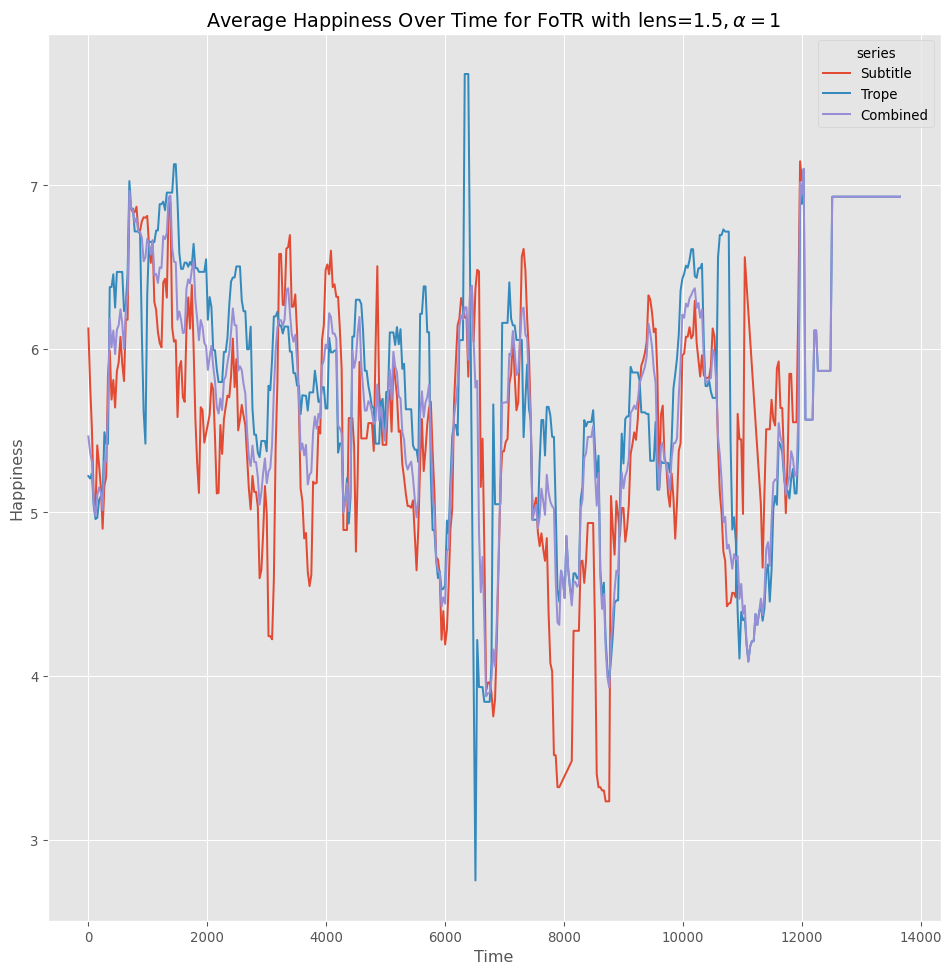

In [14]:
def plot_hedonometer(subs, tropes, lens_size, alpha, movie, ax=None):
    if not ax:
        _, ax = plt.subplots(figsize=(12, IMG_WIDTH))

    df = hedonometer_score(subtitle_df, trope_df, lens_size, alpha, step_size=30)
    melted = df.melt(
        id_vars="start",
        value_vars=["Subtitle", "Trope", "Combined"],
        var_name="series",
        value_name="happiness",
    )
    sns.lineplot(data=melted, x="start", y="happiness", hue="series", ax=ax, )
    ax.set_xlabel("Time")
    ax.set_ylabel("Happiness")
    ax.set_title(
        rf"Average Happiness Over Time for {movie} with lens=${lens_size}, \alpha={alpha}$"
    )


plot_hedonometer(subtitle_df, trope_df, 1.5, 1, "FoTR")